In [1]:
from capture_utils_v2 import CaptureSystem

# Initialize the capture system
system = CaptureSystem()


Pixel format set to RGB8
IC4 Grabber and Sink initialized.


In [2]:
system.display_drawer()


showing


MANUAL CORNER SELECTION
Click on the 4 corners of the projection area in order:
  1. Top-Left
  2. Top-Right
  3. Bottom-Right
  4. Bottom-Left
Press 'r' to reset, 'q' to quit
Corner 1/4 marked at (278, 370)
Corner 2/4 marked at (328, 370)
Corner 3/4 marked at (328, 395)
Corner 4/4 marked at (276, 396)


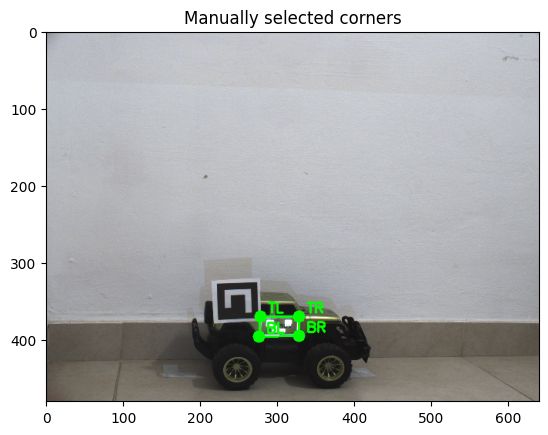

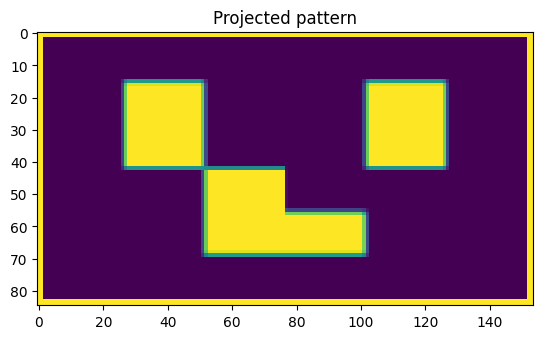

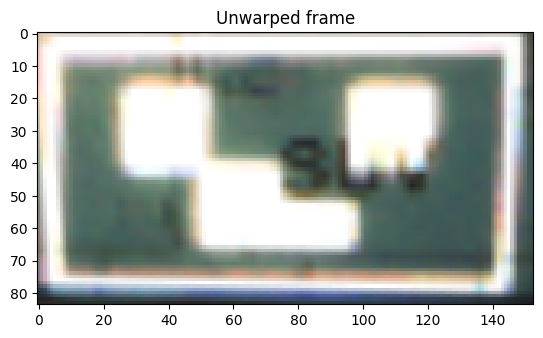

✓ Manual calibration complete!
  Corners: [[278. 370.]
 [328. 370.]
 [328. 395.]
 [276. 396.]]


In [3]:
# system.run_aruco_detector()
system.run_aruco_detector_manual()  # Instead of run_aruco_detector()

  6%|▌         | 2/33 [00:03<00:58,  1.88s/it]

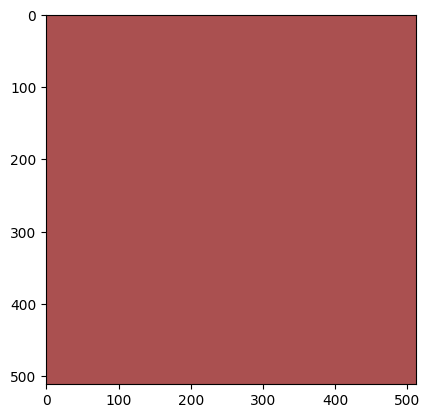

IC4 already opened, using existing grabber and sink.


  6%|▌         | 2/33 [00:05<01:21,  2.63s/it]


KeyboardInterrupt: 

In [ ]:
ret = system.photometric_calibration(return_captured=True)
# system.photometric_calibration_adaptive()

In [ ]:
# save system orig_proj_corners and corners_img_proj to a file
import pickle
with open("capture_system_state.pkl", "wb") as f:
    pickle.dump({'orig_proj_corners': system.orig_proj_corners,
                  'corners_img_proj': system.corners_img_proj, 
                  'orig_img': system.orig_img, 
                  'img_non_zero_section': system.img_non_zero_section, 
                  'H': system.H
                  }, f)

## Infer

In [4]:
# for capaa
# import sys
# sys.path.append(r'C:\git\CAPAA\src\python')
# from utils import init_prj_window

In [5]:
from capture_utils_v2 import CaptureSystem
import numpy as np
import cv2
import pickle
from aruco_pose import get_camera_angles_from_frame
# Initialize the capture system


Camera Matrix:
[[1.04739831e+03 0.00000000e+00 3.24036999e+02]
 [0.00000000e+00 9.50491793e+02 3.23897832e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients: [ 2.60138074e-01 -4.37871352e+00  3.56370583e-02 -2.58297180e-03
  2.21970709e+01]


c:\Users\danny\anaconda3\envs\py310\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [6]:
im_path = r"C:\git\PhysicalAdverserialProj\results\best_patch_ensamble_classifier_16x16_6_2025-12-27_10_24.png"
# im_path = './results/best_patch_ensamble_classifier_16x16_16_2025-12-24_10_08.png'
# im_path = r'C:\git\PhysicalAdverserialProj\results\rejuv_MobileNetV3_16x16_2026-01-18_14_56_top_patches\5_1.0.png'
# im_path = r"C:\git\PhysicalAdverserialProj\results\MobileNetV3_16x16_2026-01-20_10_58_top_patches\33_0.86.png"
# im_path = r"C:\git\PhysicalAdverserialProj\results\MobileNetV3_16x16_2026-01-20_15_43_top_patches\1_1.0.png"
# im_path = r"C:\git\PhysicalAdverserialProj\results\MobileNetV3_16x16_2026-01-20_16_26_top_patches\2_1.0.png"
image_to_project =  cv2.imread(im_path)
image_to_project = cv2.cvtColor(image_to_project, cv2.COLOR_BGR2RGB)

In [7]:
# import pickle

# system = CaptureSystem()

# # with open("capture_system_state_ablation_base_backup.pkl", "rb") as f:
# with open("capture_system_state.pkl", "rb") as f:
#     system_dict = pickle.load(f)


# system.orig_proj_corners, system.corners_img_proj, system.orig_img, system.img_non_zero_section \
#     = system_dict['orig_proj_corners'], system_dict['corners_img_proj'],system_dict['orig_img'], system_dict['img_non_zero_section']

In [8]:
system.plot_on_screen(image_to_project)

In [9]:
#capaa
# from omegaconf import DictConfig, OmegaConf
# import matplotlib as plt
# plt.use('Qt5Agg')
# p = r"C:\git\CAPAA\src\python\data\setups\jeep8\prj\adv\CAPAA_PCNet_l1+ssim_500_24_2000\camdE_caml2\5\classifier_all\img_0001.png"
# img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
# setup_info = DictConfig(dict(
#     prj_screen_sz      = (1920 , 1080),   # projector screen resolution (i.e., set in the OS)
#     prj_im_sz          = (256 , 256),   # projector input image resolution, the image will be scaled to match the prj_screen_sz by plt
#     prj_offset         = (2560,   0),   # an offset to move the projector plt figure to the correct screen (check your OS display setting)
#     prj_brightness     = 0.5,           # brightness (0~1 float) of the projector gray image for scene illumination.

#     # adjust the two params below according to your ProCams latency, until the projected and captured numbers images are correctly matched
#     delay_frames = 5,  # how many frames to drop before we capture the correct one, increase it when ProCams are not in sync
#     delay_time = 0.1,  # a delay time (s) between the project and capture operations for software sync, increase it when ProCams are not in sync
#     )
# )
# prj = init_prj_window(*setup_info['prj_screen_sz'], 0.5, setup_info['prj_offset'])
# prj.set_data(img)

In [10]:
import torch
# from classfier import predict_raw, weights
# from classfier_ensemble import predict_raw, weights
# from classfier_ensemble_v2 import predict_raw, weights
# from classfier_dino import predict_raw, weights
# from classfier_mobilenet import predict_raw, weights
# from classfier_dino import predict_raw, weights
from classfier_ensemble import predict_raw as predict_raw_ens
from classfier_mobilenet import weights

weights_dict = {
    'inception': 1.0,
    'resnet': 0.0,
    'vgg': 0.0,
    'vit': 0.0,
    'dino': 0.0
}

predict_raw = lambda x: predict_raw_ens(x, weights_dict)

Loading ensemble models...


Using cache found in C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "c:\Users\danny\anaconda3\envs\py310\lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
ModuleNotFoundError: No module named 'triton'
C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
C:\Users\danny/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


✓ All models loaded successfully!
  - Inception V3
  - ResNet18
  - VGG16
  - ViT-B/16
  - DINOv2

✓ Ensemble classifier ready!
  Main function: predict_raw(image)
  Alternatives: predict_raw_weighted(image, weights_dict)
               predict_raw_per_model(image)
               ensemble_predict(image)


In [11]:
weights.meta['categories'].index('water bottle')

898

In [12]:
forbiden_classes = [898]

In [13]:
from PIL import Image, ImageDraw, ImageFont

def add_text_with_background(img, text, position, font_size=24, text_color=(255, 255, 255), bg_color=(0, 0, 0)):
    """Add text with background using PIL (supports Arial font)"""
    # Convert BGR to RGB for PIL
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    draw = ImageDraw.Draw(pil_img)
    
    # Try to load Arial font, fall back to default if not available
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        try:
            font = ImageFont.truetype("C:/Windows/Fonts/arial.ttf", font_size)
        except:
            font = ImageFont.load_default()
    
    # Get text bounding box
    bbox = draw.textbbox(position, text, font=font)
    padding = 5
    
    # Draw black background rectangle
    draw.rectangle([bbox[0] - padding, bbox[1] - padding, 
                    bbox[2] + padding, bbox[3] + padding], fill=bg_color)
    
    # Draw white text
    draw.text(position, text, font=font, fill=text_color)
    
    # Convert back to BGR for OpenCV
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()
cap = system.cap

caps = []
caps_with_text = []
results = []
raw_predictions = []
for i in range(2400):
    r = cap.read()[1]
    tr = tt(r)
    with torch.no_grad():
        p = predict_raw(tr.unsqueeze(0).cuda())
        res = weights.meta["categories"][p[0].argmax(0).item()]
        prob = p[0].max(0).values.item() * 100
        raw_predictions.append(p)
    
    # add text
    r_orig = r.copy()
    pose_result = get_camera_angles_from_frame(r)
    
    # White text on black background with Arial font
    r = add_text_with_background(r, f'Pred: {res}: {prob:.2f}%', (10, 10), font_size=28)
    
    # Display camera angles if ArUco marker is detected
    # if pose_result['found']:
    # angle = pose_result['angle']
    # dist = pose_result['distance_m']
        # cv2.putText(r, f'H: {angle:.1f}deg  Dist: {dist:.1f}m', (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
    # else:
    #     r = add_text_with_background(r, 'ArUco not detected', (10, 50), font_size=22, text_color=(255, 100, 100))
    
    cv2.imshow('frame', r)
    results.append(res)

    caps_with_text.append(r)
    caps.append(r_orig)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        raise

RuntimeError: No active exception to reraise

In [ ]:
# save caps to disk

In [ ]:
import os
import datetime
cur_time = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
infer_caps_dir = r"C:\git\PhysicalAdverserialProj\infer_caps_dir"
exp_name = rf"{os.path.basename(im_path).split('.')[0]}"
# exp_name = "capaa_jeep8_5_1"
os.makedirs(f"{infer_caps_dir}/{exp_name}/{cur_time}/")
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/caps.pkl", "wb") as f:
    pickle.dump(caps, f)
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/caps_with_text.pkl", "wb") as f:
    pickle.dump(caps_with_text, f)
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/results.pkl", "wb") as f:
    pickle.dump(results, f)
with open(f"{infer_caps_dir}/{exp_name}/{cur_time}/raw_predictions.pkl", "wb") as f:
    pickle.dump(raw_predictions, f)

In [14]:
cv2.destroyAllWindows()

### With tracking

### Tracking with Rotation Compensation
Uses SIFT tracking to adjust the existing projection (from `system.plot_on_screen`) to compensate for object movement and rotation.

In [14]:
# Optional: Load ProCam stereo calibration for future 3D-aware projection
# For now, we use the existing system calibration (system.orig_proj_corners, etc.)

import pickle
import os
import numpy as np

CALIB_DIR = r"C:\git\PhysicalAdverserialProj\procam_calibration_data"
calib_file = os.path.join(CALIB_DIR, 'procam_calibration_aruco.pkl')

if os.path.exists(calib_file):
    with open(calib_file, 'rb') as f:
        procam_calib = pickle.load(f)
    print(f"✓ ProCam calibration loaded from {calib_file}")
    print(f"  Stereo RMS error: {procam_calib.get('stereo_rms_error', 'N/A'):.4f} px")
    print(f"  Baseline: {np.linalg.norm(procam_calib['T']):.1f} mm")
else:
    print(f"⚠ ProCam calibration not found at {calib_file}")
    print("  Using system's photometric calibration only")
    procam_calib = None

✓ ProCam calibration loaded from C:\git\PhysicalAdverserialProj\procam_calibration_data\procam_calibration_aruco.pkl
  Stereo RMS error: 0.5653 px
  Baseline: 353.4 mm


In [15]:
# from classfier import *
# from tracking_utils import TrackerSystem
# image_to_project =  patch = cv2.imread(r'C:\git\PhysicalAdverserialProj\results\best_patch_16x16_1_2025-12-13_16_22.png')

# tracker = TrackerSystem(system, predict_raw, weights, printed_aruco_id=10)
# caps, results = tracker.track_project_and_classify(image_to_project)

In [33]:
# ============================================================================
# ARUCO TRACKING + STEREO PROJECTION + CLASSIFICATION
# ============================================================================
# Projects patch that MOVES with the ArUco marker using 3D ProCam stereo calibration.
# Projection follows the marker in real-time, robust to rotations and translations.

import cv2
import cv2.aruco as aruco
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont

# Helper functions
tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()

def add_text_with_background(img, text, position, font_size=24, text_color=(255,255,255), bg_color=(0,0,0)):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    draw = ImageDraw.Draw(pil_img)
    try:
        font = ImageFont.truetype("C:/Windows/Fonts/arial.ttf", font_size)
    except:
        font = ImageFont.load_default()
    bbox = draw.textbbox(position, text, font=font)
    padding = 5
    draw.rectangle([bbox[0]-padding, bbox[1]-padding, bbox[2]+padding, bbox[3]+padding], fill=bg_color)
    draw.text(position, text, font=font, fill=text_color)
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

# ============================================================================
# CONFIGURATION
# ============================================================================

ARUCO_DICT_TYPE = aruco.DICT_4X4_50
ARUCO_MARKER_SIZE_MM = 60.0  # 6 cm
ARUCO_MARKER_ID = -1  # -1 = any, or specify ID

# Load all calibration from procam_calibration_aruco.pkl
camera_matrix = procam_calib['camera_matrix'].copy()
camera_dist = procam_calib['camera_dist']
projector_matrix = procam_calib['projector_matrix']
projector_dist = procam_calib.get('projector_dist', np.zeros(5))
R_stereo = procam_calib['R']  # Rotation from camera to projector
T_stereo = procam_calib['T']  # Translation from camera to projector

# Check actual frame resolution and scale camera matrix if needed
ret, test_frame = system.cap.read()
if ret:
    actual_h, actual_w = test_frame.shape[:2]
    # Camera matrix cx, cy suggest calibration resolution
    calib_w = int(camera_matrix[0, 2] * 2)  # cx is ~half width
    calib_h = int(camera_matrix[1, 2] * 2)  # cy is ~half height
    print(f"Calibration resolution (estimated): {calib_w}x{calib_h}")
    print(f"Actual frame resolution: {actual_w}x{actual_h}")
    
    if actual_w != calib_w or actual_h != calib_h:
        scale_x = actual_w / calib_w
        scale_y = actual_h / calib_h
        print(f"⚠ Resolution mismatch! Scaling camera matrix by ({scale_x:.2f}, {scale_y:.2f})")
        camera_matrix[0, 0] *= scale_x  # fx
        camera_matrix[1, 1] *= scale_y  # fy
        camera_matrix[0, 2] *= scale_x  # cx
        camera_matrix[1, 2] *= scale_y  # cy

print(f"Camera matrix: fx={camera_matrix[0,0]:.1f}, fy={camera_matrix[1,1]:.1f}, cx={camera_matrix[0,2]:.1f}, cy={camera_matrix[1,2]:.1f}")
print(f"Projector matrix: fx={projector_matrix[0,0]:.1f}, fy={projector_matrix[1,1]:.1f}")

PROJECTOR_X_OFFSET = 1920
PRJ_W, PRJ_H = system.screen_res

# Smoothing parameters - lower values = more smoothing but more lag
# Higher values = more responsive but more jitter
CORNER_SMOOTH_ALPHA = 0.5   # EMA for detected corners (0.3->0.5 for faster response)
POSE_SMOOTH_ALPHA = 0.4     # EMA for pose (0.2->0.4 for faster response during rotation)

# Patch to project
patch = cv2.imread(im_path)
patch_h, patch_w = patch.shape[:2]
src_corners = np.array([[0,0],[patch_w,0],[patch_w,patch_h],[0,patch_h]], dtype=np.float32)

# ============================================================================
# 3D PATCH CONFIGURATION - Relative to marker center
# ============================================================================
# Similar to debug_aruco_projection.ipynb: define patch position in marker frame.
# Will be computed during initialization by back-projecting system.corners_img_proj.

patch_3d_corners = None  # Set during initialization: 4x3 array in marker coords

def camera_pixel_to_marker_3d(pixel, rvec, tvec):
    """Back-project a camera pixel to 3D on the marker plane (Z=0)."""
    pixel_undist = cv2.undistortPoints(
        np.array([[pixel]], dtype=np.float32),
        camera_matrix, camera_dist, P=camera_matrix
    )[0, 0]
    
    R_cam, _ = cv2.Rodrigues(rvec)
    fx, fy = camera_matrix[0, 0], camera_matrix[1, 1]
    cx, cy = camera_matrix[0, 2], camera_matrix[1, 2]
    
    ray_cam = np.array([
        (pixel_undist[0] - cx) / fx,
        (pixel_undist[1] - cy) / fy,
        1.0
    ])
    
    cam_pos_marker = -R_cam.T @ tvec.flatten()
    ray_marker = R_cam.T @ ray_cam
    
    if abs(ray_marker[2]) < 1e-6:
        return None
    
    lambda_val = -cam_pos_marker[2] / ray_marker[2]
    if lambda_val < 0:
        return None
    
    point_3d = cam_pos_marker + lambda_val * ray_marker
    point_3d[2] = 0
    return point_3d.astype(np.float32)

print("Patch 3D corners will be computed from corners_img_proj during init.")

# ============================================================================
# STEREO PROJECTION FUNCTION
# ============================================================================

def project_to_projector_3d(pts_3d, rvec_cam, tvec_cam):
    """Project 3D object-frame points to projector pixel coordinates via stereo.
    
    Pipeline (matching debug_aruco_projection.ipynb):
      1. Camera extrinsics: R_cam, t_cam from solvePnP (object → camera)
      2. Stereo transform: R_proj = R_st @ R_cam, t_proj = R_st @ t_cam + T_st (object → projector)
      3. projectPoints with projector intrinsics
    """
    R_cam, _ = cv2.Rodrigues(rvec_cam)
    R_proj = R_stereo @ R_cam
    t_proj = (R_stereo @ tvec_cam.flatten() + T_stereo.flatten()).reshape(3, 1)
    rvec_proj, _ = cv2.Rodrigues(R_proj)
    
    pts, _ = cv2.projectPoints(pts_3d, rvec_proj, t_proj, projector_matrix, projector_dist)
    return pts.reshape(-1, 2).astype(np.float32)

# ============================================================================
# ARUCO SETUP
# ============================================================================

aruco_dict = aruco.getPredefinedDictionary(ARUCO_DICT_TYPE)
aruco_params = aruco.DetectorParameters()
aruco_params.cornerRefinementMethod = aruco.CORNER_REFINE_SUBPIX
aruco_params.cornerRefinementWinSize = 5
aruco_params.cornerRefinementMaxIterations = 30
aruco_params.cornerRefinementMinAccuracy = 0.01
aruco_detector = aruco.ArucoDetector(aruco_dict, aruco_params)

# 3D marker corners (OpenCV ArUco convention: Y increases downward)
half_m = ARUCO_MARKER_SIZE_MM / 2.0
marker_obj_points = np.array([
    [-half_m, -half_m, 0],   # top-left
    [ half_m, -half_m, 0],   # top-right
    [ half_m,  half_m, 0],   # bottom-right
    [-half_m,  half_m, 0],   # bottom-left
], dtype=np.float32)

# State for smoothing
smoothed_corners = None
smoothed_rvec = None
smoothed_tvec = None

def detect_aruco_with_pose(frame):
    """Detect ArUco marker and estimate pose. Returns smoothed results."""
    global smoothed_corners, smoothed_rvec, smoothed_tvec
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if len(frame.shape) == 3 else frame
    corners, ids, _ = aruco_detector.detectMarkers(gray)
    
    if ids is None or len(ids) == 0:
        return False, None, None, None, None
    
    idx = 0
    if ARUCO_MARKER_ID >= 0:
        for i, mid in enumerate(ids):
            if mid[0] == ARUCO_MARKER_ID:
                idx = i
                break
        else:
            return False, None, None, None, None
    
    mc = corners[idx].reshape(-1, 2).astype(np.float32)
    mid = int(ids[idx][0])
    
    # Smooth corners first
    if smoothed_corners is None:
        smoothed_corners = mc.copy()
    else:
        smoothed_corners = CORNER_SMOOTH_ALPHA * mc + (1 - CORNER_SMOOTH_ALPHA) * smoothed_corners
    
    # Estimate pose from smoothed corners
    if smoothed_rvec is not None and smoothed_tvec is not None:
        success, rvec, tvec = cv2.solvePnP(
            marker_obj_points, smoothed_corners, camera_matrix, camera_dist,
            rvec=smoothed_rvec.copy(), tvec=smoothed_tvec.copy(),
            useExtrinsicGuess=True, flags=cv2.SOLVEPNP_ITERATIVE
        )
    else:
        # First detection - try multiple solvePnP methods and pick best one
        # First, print debug info about corners
        corner_span = np.max(smoothed_corners, axis=0) - np.min(smoothed_corners, axis=0)
        print(f"[DEBUG] Detected corners span: {corner_span[0]:.1f} x {corner_span[1]:.1f} pixels")
        print(f"[DEBUG] marker_obj_points span: {ARUCO_MARKER_SIZE_MM} mm")
        print(f"[DEBUG] Camera fx={camera_matrix[0,0]:.1f}, fy={camera_matrix[1,1]:.1f}")
        
        # Expected distance: if marker spans 'p' pixels, and actual size is 'S' mm,
        # distance ≈ S * f / p
        expected_z = ARUCO_MARKER_SIZE_MM * camera_matrix[0,0] / corner_span[0]
        print(f"[DEBUG] Expected Z distance: ~{expected_z:.0f} mm")
        
        # Use SOLVEPNP_IPPE_SQUARE to get both solutions
        retval, rvecs, tvecs, reproj_errors = cv2.solvePnPGeneric(
            marker_obj_points, smoothed_corners, camera_matrix, camera_dist,
            flags=cv2.SOLVEPNP_IPPE_SQUARE
        )
        
        if retval == 0 or len(rvecs) == 0:
            return False, None, None, None, None
        
        # Print both solutions for debugging
        print(f"[IPPE] Solution 0: tvec={tvecs[0].flatten()}, reproj_err={reproj_errors[0][0] if reproj_errors is not None else 'N/A'}")
        if len(tvecs) > 1:
            print(f"[IPPE] Solution 1: tvec={tvecs[1].flatten()}, reproj_err={reproj_errors[1][0] if reproj_errors is not None else 'N/A'}")
        
        # Pick the solution with Z closest to expected_z (and positive)
        best_idx = 0
        best_diff = float('inf')
        for i, tv in enumerate(tvecs):
            z = tv[2, 0]
            if z > 0:
                diff = abs(z - expected_z)
                if diff < best_diff:
                    best_diff = diff
                    best_idx = i
        
        rvec = rvecs[best_idx]
        tvec = tvecs[best_idx]
        success = True
        print(f"[IPPE] Selected: {best_idx} (Z={tvec[2,0]:.1f}mm)")
    
    if not success:
        return False, None, None, None, None
    
    # Sanity check: Z should be positive (marker in front of camera)
    if tvec[2, 0] < 0:
        # Flip the pose by rotating 180 degrees around X axis
        R, _ = cv2.Rodrigues(rvec)
        R_flip = np.array([[1, 0, 0], [0, -1, 0], [0, 0, -1]], dtype=np.float64)
        R = R @ R_flip
        rvec, _ = cv2.Rodrigues(R)
        tvec = -tvec
    
    # Check for pose flip (normal pointing wrong direction = Z axis flip)
    R, _ = cv2.Rodrigues(rvec)
    normal = R[:, 2]  # Z-axis of marker in camera frame
    
    if smoothed_rvec is not None:
        R_prev, _ = cv2.Rodrigues(smoothed_rvec)
        normal_prev = R_prev[:, 2]
        # If normal flipped (dot product negative), reject this pose
        if np.dot(normal, normal_prev) < 0:
            # Pose flipped - keep previous pose
            return True, smoothed_rvec, smoothed_tvec, smoothed_corners, mid
    
    # Smooth pose
    if smoothed_rvec is None:
        smoothed_rvec = rvec.copy()
        smoothed_tvec = tvec.copy()
    else:
        smoothed_rvec = POSE_SMOOTH_ALPHA * rvec + (1 - POSE_SMOOTH_ALPHA) * smoothed_rvec
        smoothed_tvec = POSE_SMOOTH_ALPHA * tvec + (1 - POSE_SMOOTH_ALPHA) * smoothed_tvec
    
    return True, smoothed_rvec, smoothed_tvec, smoothed_corners, mid

# ============================================================================
# WINDOW SETUP
# ============================================================================

cv2.namedWindow("Projector", cv2.WND_PROP_FULLSCREEN)
cv2.moveWindow("Projector", PROJECTOR_X_OFFSET, 0)
cv2.setWindowProperty("Projector", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
cv2.namedWindow("Preview", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Preview", 1280, 960)

# Initial blank projection
proj_img = np.zeros((PRJ_H, PRJ_W, 3), dtype=np.uint8)
cv2.imshow("Projector", proj_img)
cv2.waitKey(100)

# ============================================================================
# TRACKING LOOP (with initialization phase)
# ============================================================================

print("=" * 60)
print("ARUCO TRACKING + STEREO PROJECTION + CLASSIFICATION")
print("=" * 60)
print(f"Stereo baseline: {np.linalg.norm(T_stereo):.1f} mm")
print("=" * 60)

# --- INITIALIZATION PHASE ---
# Project calibrated corners to camera, detect marker, compute 3D patch corners
print("\n--- INITIALIZATION PHASE ---")
print("Projecting calibration pattern and detecting marker...")

# Get calibrated projection corners from photometric calibration
calib_proj_corners = system.orig_proj_corners.reshape(-1, 2).astype(np.float32)
print(f"Calibrated projector corners:\n{calib_proj_corners}")

# Project the patch at calibrated position
M_init = cv2.getPerspectiveTransform(src_corners, calib_proj_corners)
init_proj_img = cv2.warpPerspective(patch, M_init, (PRJ_W, PRJ_H))
cv2.imshow("Projector", init_proj_img)
cv2.waitKey(500)

# Capture frames until marker is detected stably
init_success = False
init_frames = 0
MAX_INIT_FRAMES = 300

smoothed_corners = None
smoothed_rvec = None
smoothed_tvec = None

while init_frames < MAX_INIT_FRAMES:
    ret, frame = system.cap.read()
    if not ret:
        continue
    
    init_frames += 1
    display = frame.copy()
    
    ok, rvec, tvec, mc, mid = detect_aruco_with_pose(frame)
    
    if ok:
        # Draw marker and pose
        cv2.polylines(display, [mc.astype(np.int32)], True, (0, 255, 0), 2)
        
        # DEBUG: Print pose info
        tf = tvec.flatten()
        rf = rvec.flatten()
        R_dbg, _ = cv2.Rodrigues(rvec)
        print(f"[INIT] rvec=({rf[0]:.3f}, {rf[1]:.3f}, {rf[2]:.3f}) tvec=({tf[0]:.1f}, {tf[1]:.1f}, {tf[2]:.1f}) normal=({R_dbg[0,2]:.2f}, {R_dbg[1,2]:.2f}, {R_dbg[2,2]:.2f})")
        
        cv2.drawFrameAxes(display, camera_matrix, camera_dist, rvec, tvec, 30)
        
        # Draw where calibrated corners appear in camera
        # Back-project projector corners to camera coordinates
        # We need to find where the projected patch lands in the camera image
        # Use the current corners_img_proj if available, otherwise estimate
        if hasattr(system, 'corners_img_proj') and system.corners_img_proj is not None:
            cam_corners = system.corners_img_proj.reshape(-1, 2).astype(np.int32)
            cv2.polylines(display, [cam_corners], True, (255, 0, 255), 2)
            cv2.putText(display, "Magenta=Calibrated area", (10, 90), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)
        
        cv2.putText(display, f"INIT: Marker detected! Frame {init_frames}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(display, "Press SPACE to confirm, Q to quit", (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
    else:
        cv2.putText(display, f"INIT: Looking for marker... Frame {init_frames}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    
    cv2.imshow("Preview", display)
    key = cv2.waitKey(30) & 0xFF
    
    if key == ord(' ') and ok:
        # User confirmed - compute 3D patch corners in marker frame
        tf = tvec.flatten()
        print(f"\n✓ Marker ID {mid} detected")
        print(f"  tvec = ({tf[0]:.1f}, {tf[1]:.1f}, {tf[2]:.1f}) mm")
        print(f"  Distance from camera: {np.linalg.norm(tf):.1f} mm")
        
        # Sanity check: distance should be reasonable (200-1000mm typical)
        if np.linalg.norm(tf) < 100:
            print(f"⚠ WARNING: Marker distance {np.linalg.norm(tf):.1f}mm seems too close!")
            print(f"  Camera matrix fx,fy = {camera_matrix[0,0]:.1f}, {camera_matrix[1,1]:.1f}")
        
        # Use camera corners from photometric calibration
        if hasattr(system, 'corners_img_proj') and system.corners_img_proj is not None:
            cam_corners = system.corners_img_proj.reshape(-1, 2)
        else:
            print("⚠ corners_img_proj not available, using estimated positions")
            # Fallback: project projector corners through stereo calibration (inverse)
            cam_corners = calib_proj_corners  # This won't be accurate but prevents crash
        
        # Back-project each camera corner to 3D on marker plane
        patch_3d_corners_marker = []
        for i, cam_pt in enumerate(cam_corners):
            pt_3d = camera_pixel_to_marker_3d(cam_pt, rvec, tvec)
            if pt_3d is not None:
                patch_3d_corners_marker.append(pt_3d)
                print(f"  Corner {i}: camera ({cam_pt[0]:.0f}, {cam_pt[1]:.0f}) -> 3D ({pt_3d[0]:.1f}, {pt_3d[1]:.1f}, {pt_3d[2]:.1f}) mm")
            else:
                print(f"  Corner {i}: FAILED to back-project!")
        
        if len(patch_3d_corners_marker) == 4:
            patch_3d_corners_marker = np.array(patch_3d_corners_marker, dtype=np.float32)
            # Compute patch dimensions
            width = np.linalg.norm(patch_3d_corners_marker[1] - patch_3d_corners_marker[0])
            height = np.linalg.norm(patch_3d_corners_marker[3] - patch_3d_corners_marker[0])
            center = patch_3d_corners_marker.mean(axis=0)
            print(f"\n✓ Patch 3D corners computed:")
            print(f"  Size: {width:.1f} x {height:.1f} mm")
            print(f"  Center: ({center[0]:.1f}, {center[1]:.1f}) mm from marker")
            print(f"  3D corners (marker frame):\n{patch_3d_corners_marker}")
            
            # Test projection: project these corners back to projector
            test_proj = project_to_projector_3d(patch_3d_corners_marker, rvec, tvec)
            print(f"  Test projection to projector: {test_proj.tolist()}")
            print(f"  Projector size: {PRJ_W}x{PRJ_H}")
            print(f"  Original calib_proj_corners: {calib_proj_corners.tolist()}")
            
            # Also test: project the MARKER corners (should work like debug notebook)
            marker_proj = project_to_projector_3d(marker_obj_points, rvec, tvec)
            print(f"  Marker corners projection: {marker_proj.tolist()}")
            
            init_success = True
            break
        else:
            print("⚠ Could not compute all 4 corners. Try again.")
    
    elif key == ord('q'):
        break

if not init_success:
    print("\n✗ Initialization failed!")
    cv2.destroyAllWindows()
    raise RuntimeError("Could not initialize - marker not detected or corners not computed")

# --- TRACKING PHASE ---
print("\n--- TRACKING PHASE ---")
print("  q=quit | d=toggle debug")
print("=" * 60)

caps = []
caps_with_text = []
results = []
raw_predictions = []

frame_idx = 1
fps_start = cv2.getTickCount()
fps = 0
show_debug = True
lost_count = 0
last_proj_corners = None

try:
    while True:
        ret, frame = system.cap.read()
        if not ret:
            continue
        
        display = frame.copy()
        ok, rvec, tvec, mc, mid = detect_aruco_with_pose(frame)
        
        if ok:
            lost_count = 0
            
            # Project patch 3D corners to projector coordinates
            proj_corners = project_to_projector_3d(patch_3d_corners_marker, rvec, tvec)
            last_proj_corners = proj_corners
            
            # Debug: print projected corners every 60 frames
            if frame_idx % 60 == 1:
                print(f"Frame {frame_idx}: proj_corners = {proj_corners.tolist()}")
                print(f"  Bounds check: x=[{proj_corners[:,0].min():.0f}, {proj_corners[:,0].max():.0f}], y=[{proj_corners[:,1].min():.0f}, {proj_corners[:,1].max():.0f}]")
                print(f"  Projector size: {PRJ_W}x{PRJ_H}")
            
            # Warp patch to projector
            M = cv2.getPerspectiveTransform(src_corners, proj_corners)
            proj_img = cv2.warpPerspective(patch, M, (PRJ_W, PRJ_H))
            
            if show_debug and mc is not None:
                # Draw detected ArUco corners (green)
                cv2.polylines(display, [mc.astype(np.int32)], True, (0, 255, 0), 2)
                for i, c in enumerate(mc):
                    cv2.circle(display, tuple(c.astype(int)), 4, (0, 255, 0), -1)
                
                # Draw pose axes with debug
                tf_dbg = tvec.flatten()
                rf_dbg = rvec.flatten()
                R_dbg, _ = cv2.Rodrigues(rvec)
                if frame_idx % 30 == 1:
                    print(f"[TRACK] rvec=({rf_dbg[0]:.3f}, {rf_dbg[1]:.3f}, {rf_dbg[2]:.3f}) tvec=({tf_dbg[0]:.1f}, {tf_dbg[1]:.1f}, {tf_dbg[2]:.1f}) norm=({R_dbg[0,2]:.2f}, {R_dbg[1,2]:.2f}, {R_dbg[2,2]:.2f})")
                cv2.drawFrameAxes(display, camera_matrix, camera_dist, rvec, tvec, 20)
                
                # Draw expected patch location in camera frame (cyan)
                cam_patch_pts, _ = cv2.projectPoints(patch_3d_corners_marker, rvec, tvec, camera_matrix, camera_dist)
                cam_patch_pts = cam_patch_pts.reshape(-1, 2).astype(np.int32)
                cv2.polylines(display, [cam_patch_pts], True, (255, 255, 0), 2)
            
            tf = tvec.flatten()
            status = f"TRACKING | Z={tf[2]:.0f}mm | ID={mid}"
            status_color = (0, 255, 0)
        else:
            lost_count += 1
            status = f"LOST ({lost_count} frames)"
            status_color = (0, 0, 255)
            # Keep last projection when lost (don't blank out)
            if last_proj_corners is None:
                proj_img = np.zeros((PRJ_H, PRJ_W, 3), dtype=np.uint8)
        
        cv2.imshow("Projector", proj_img)
        
        # Classification
        with torch.no_grad():
            img_tensor = tt(frame).unsqueeze(0).cuda()
            probs = predict_raw(img_tensor)
            pred_class = weights.meta["categories"][probs[0].argmax().item()]
            pred_prob = probs[0].max().item() * 100
            raw_predictions.append(probs)
            pred_prob = probs[0].max().item() * 100
        display = add_text_with_background(display, f'Pred: {pred_class}: {pred_prob:.1f}%',
                                            (10, 10), font_size=24)
        display = add_text_with_background(display, status, (10, 50), font_size=18,
                                            text_color=status_color)
        
        if frame_idx % 30 == 0:
            fps = 30 / ((cv2.getTickCount() - fps_start) / cv2.getTickFrequency())
            fps_start = cv2.getTickCount()
        display = add_text_with_background(display, f'FPS: {fps:.1f} | Frame: {frame_idx}',
                                           (10, 90), font_size=16)
        
        cv2.imshow("Preview", display)
        
        caps.append(frame.copy())
        caps_with_text.append(display)
        results.append(pred_class)
        frame_idx += 1
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('d'):
            show_debug = not show_debug

except KeyboardInterrupt:
    print("\\nInterrupted")

cv2.destroyAllWindows()

print(f"\\n✓ Captured {len(caps)} frames")

if raw_predictions and 'forbiden_classes' in dir():
    success_count = sum(1 for p in raw_predictions if p[0].argmax().item() not in forbiden_classes)
    success_rate = success_count / len(raw_predictions) * 100
    print(f"  Attack Success Rate: {success_rate:.1f}% ({success_count}/{len(raw_predictions)} frames)")  

Calibration resolution (estimated): 640x489
Actual frame resolution: 640x480
⚠ Resolution mismatch! Scaling camera matrix by (1.00, 0.98)
Camera matrix: fx=912.6, fy=803.5, cx=320.3, cy=240.1
Projector matrix: fx=3128.6, fy=3128.6
Patch 3D corners will be computed from corners_img_proj during init.
ARUCO TRACKING + STEREO PROJECTION + CLASSIFICATION
Stereo baseline: 353.4 mm

--- INITIALIZATION PHASE ---
Projecting calibration pattern and detecting marker...
Calibrated projector corners:
[[799. 866.]
 [952. 866.]
 [952. 950.]
 [799. 950.]]
[DEBUG] Detected corners span: 56.0 x 50.7 pixels
[DEBUG] marker_obj_points span: 60.0 mm
[DEBUG] Camera fx=912.6, fy=803.5
[DEBUG] Expected Z distance: ~978 mm
[IPPE] Solution 0: tvec=[  1.15839894  -1.91373906 -15.22036935], reproj_err=18708788.0
[IPPE] Solution 1: tvec=[  1.40135758  -2.0169587  -15.12018421], reproj_err=249045360.0
[IPPE] Selected: 0 (Z=-15.2mm)
[INIT] rvec=(-0.178, 0.072, -0.101) tvec=(-1.2, 1.9, 15.2) normal=(0.08, 0.17, 0.98)


In [32]:
frame.shape

(480, 640, 3)

## Create GIF

In [ ]:
import imageio

captures = caps
# Create GIF from captures
captures_rgb = [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in captures]
output_gif_path = 'tracked_jeep_16x16_1_2025-12-13_16_22_inception_v3.gif'
imageio.mimsave(output_gif_path, captures_rgb, fps=14, loop=0)
print(f"GIF saved to {output_gif_path} with {len(captures)} frames")

In [ ]:
#

## Create MP4

In [ ]:
im_path

In [ ]:
import cv2
import os
import datetime

# Get frame dimensions from first frame
height, width = caps_with_text[0].shape[:2]
fps = 15  # Adjust as needed

# Create output folder with timestamp
cur_time = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
exp_name = os.path.basename(im_path).split(".")[0]
output_folder = os.path.join(r"C:\git\PhysicalAdverserialProj\captured_videos", f"{exp_name}_{cur_time}")
os.makedirs(output_folder, exist_ok=True)

# Create output filename in the new folder
output_video_path = os.path.join(output_folder, f'captured_video.mp4')

# Create VideoWriter with mp4v codec
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Write all frames
for frame in caps_with_text:
    out.write(frame)

# Release the writer
out.release()

print(f"✓ Video saved to '{output_video_path}'")
print(f"  - Output folder: {output_folder}")
print(f"  - Frames: {len(caps_with_text)}")
print(f"  - Resolution: {width}x{height}")
print(f"  - FPS: {fps}")
print(f"  - Duration: {len(caps_with_text)/fps:.1f} seconds")

## Post capture analysis

In [ ]:
# Setup for analysis
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import pickle
import importlib

# Import orig_clases - vehicle classes we want to avoid
import consts
importlib.reload(consts)
orig_clases = consts.orig_clases

from aruco_pose import get_camera_angles_from_frame

# Load camera calibration for ArUco detection
cameraMatrix, dist_coeffs = pickle.load(open(r"C:\git\wall_alignment\calibration.pkl", "rb"))

tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()

print(f"Original vehicle classes to avoid: {orig_clases.tolist()}")
print(f"Number of captured frames: {len(caps)}")

In [ ]:
# Load all classifiers for evaluation
print("Loading classifiers...")

# Ensemble v1 classifier (Inception, ResNet, VGG, ViT, DINOv2)
import classfier_ensemble as ensemble_v1
ensemble_v1_weights = ensemble_v1.weights
print("✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)")

# Ensemble v2 classifier (ConvNeXt, EfficientNet, MobileNet, Swin)
import classfier_ensemble_v2 as ensemble_v2
ensemble_v2_weights = ensemble_v2.weights
print("✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)")

# DINOv2 standalone classifier
import classfier_dino as dino
dino_weights = dino.weights
print("✓ DINOv2 standalone classifier loaded")

categories = ensemble_v1_weights.meta["categories"]
print(f"\n✓ All classifiers ready for evaluation")

In [ ]:
# Analyze all captured frames - extract pose info and classify with all models
results_list = []

for frame_idx, frame in enumerate(tqdm(caps, desc="Analyzing frames")):
    # Get ArUco pose (angle and distance)
    pose_result = get_camera_angles_from_frame(frame)
    
    if not pose_result['found']:
        continue  # Skip frames without ArUco marker
    
    angle = pose_result['angle']
    distance = pose_result['distance_m']
    
    # Prepare image tensor
    img_tensor = tt(frame).unsqueeze(0).cuda()
    
    with torch.no_grad():
        # Get predictions from each model in ensemble v1
        ensemble_v1_per_model = ensemble_v1.predict_raw_per_model(img_tensor)
        
        # Get predictions from each model in ensemble v2
        ensemble_v2_per_model = ensemble_v2.predict_raw_per_model(img_tensor)
        
        # Get DINOv2 standalone prediction
        dino_probs = dino.predict_raw(img_tensor)
    
    # Build result row
    result_row = {
        'frame_idx': frame_idx,
        'angle_deg': angle,
        'distance_m': distance,
    }
    
    # Process ensemble v1 models (individual) - Inception, ResNet, VGG, ViT, DINOv2
    for model_name in ['inception', 'resnet', 'vgg', 'vit', 'dino']:
        if model_name in ensemble_v1_per_model:
            probs = ensemble_v1_per_model[model_name]
            pred_idx = probs[0].argmax().item()
            pred_conf = probs[0][pred_idx].item()
            pred_class = categories[pred_idx]
            
            # Check if attack is successful (prediction NOT in orig_clases)
            is_success = pred_idx not in orig_clases.tolist()
            
            result_row[f'v1_{model_name}_class'] = pred_class
            result_row[f'v1_{model_name}_idx'] = pred_idx
            result_row[f'v1_{model_name}_conf'] = pred_conf
            result_row[f'v1_{model_name}_success'] = is_success
    
    # Ensemble v1 combined prediction
    if 'ensemble' in ensemble_v1_per_model:
        ens_probs = ensemble_v1_per_model['ensemble']
        ens_pred_idx = ens_probs[0].argmax().item()
        ens_pred_conf = ens_probs[0][ens_pred_idx].item()
        ens_pred_class = categories[ens_pred_idx]
        ens_is_success = ens_pred_idx not in orig_clases.tolist()
        
        result_row['v1_combined_class'] = ens_pred_class
        result_row['v1_combined_idx'] = ens_pred_idx
        result_row['v1_combined_conf'] = ens_pred_conf
        result_row['v1_combined_success'] = ens_is_success
    
    # Process ensemble v2 models (individual) - ConvNeXt, EfficientNet, MobileNet, Swin
    for model_name in ['convnext', 'efficientnet', 'mobilenet', 'swin']:
        if model_name in ensemble_v2_per_model:
            probs = ensemble_v2_per_model[model_name]
            pred_idx = probs[0].argmax().item()
            pred_conf = probs[0][pred_idx].item()
            pred_class = categories[pred_idx]
            
            # Check if attack is successful (prediction NOT in orig_clases)
            is_success = pred_idx not in orig_clases.tolist()
            
            result_row[f'v2_{model_name}_class'] = pred_class
            result_row[f'v2_{model_name}_idx'] = pred_idx
            result_row[f'v2_{model_name}_conf'] = pred_conf
            result_row[f'v2_{model_name}_success'] = is_success
    
    # Ensemble v2 combined prediction
    if 'ensemble' in ensemble_v2_per_model:
        ens_probs = ensemble_v2_per_model['ensemble']
        ens_pred_idx = ens_probs[0].argmax().item()
        ens_pred_conf = ens_probs[0][ens_pred_idx].item()
        ens_pred_class = categories[ens_pred_idx]
        ens_is_success = ens_pred_idx not in orig_clases.tolist()
        
        result_row['v2_combined_class'] = ens_pred_class
        result_row['v2_combined_idx'] = ens_pred_idx
        result_row['v2_combined_conf'] = ens_pred_conf
        result_row['v2_combined_success'] = ens_is_success
    
    # DINOv2 standalone
    dino_pred_idx = dino_probs[0].argmax().item()
    dino_pred_conf = dino_probs[0][dino_pred_idx].item()
    dino_pred_class = categories[dino_pred_idx]
    dino_is_success = dino_pred_idx not in orig_clases.tolist()
    
    result_row['dino_standalone_class'] = dino_pred_class
    result_row['dino_standalone_idx'] = dino_pred_idx
    result_row['dino_standalone_conf'] = dino_pred_conf
    result_row['dino_standalone_success'] = dino_is_success
    
    results_list.append(result_row)

print(f"\n✓ Analyzed {len(results_list)} frames with ArUco marker detected")
df = pd.DataFrame(results_list)

In [ ]:
%matplotlib inline

In [ ]:
# Calculate and display success rates per model with clear v1/v2/dino distinction
print("="*80)
print("ATTACK SUCCESS RATE ANALYSIS")
print("="*80)
print(f"\nSuccess = classifier output NOT in orig_clases (vehicle classes)")
print(f"Total frames analyzed: {len(df)}")
print(f"Angle range: {df['angle_deg'].min():.1f}° to {df['angle_deg'].max():.1f}°")
print(f"Distance range: {df['distance_m'].min():.2f}m to {df['distance_m'].max():.2f}m")

# Get all success columns
success_cols = [c for c in df.columns if c.endswith('_success')]

# Define model groups for clear display - DINOv2 standalone only
v1_models = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_combined']
dino_models = ['dino_standalone']  # Only standalone DINOv2
v2_models = ['v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin', 'v2_combined']

# Display names mapping
display_names = {
    'v1_inception': 'Inception V3',
    'v1_resnet': 'ResNet18',
    'v1_vgg': 'VGG16',
    'v1_vit': 'ViT-B/16',
    'v1_combined': '*** COMBINED ***',
    'v2_convnext': 'ConvNeXt Base',
    'v2_efficientnet': 'EfficientNet B0',
    'v2_mobilenet': 'MobileNetV3 Large',
    'v2_swin': 'Swin Transformer',
    'v2_combined': '*** COMBINED ***',
    'dino_standalone': 'DINOv2',
}

success_summary = []

def print_model_results(model_list, df, success_summary, group_name):
    for model_name in model_list:
        success_col = f'{model_name}_success'
        if success_col in df.columns:
            success_count = df[success_col].sum()
            total_count = len(df)
            success_rate = success_count / total_count * 100
            
            display = display_names.get(model_name, model_name)
            print(f"  {display:<25} {success_rate:>10.1f}% {success_count:>10} / {total_count:<8}")
            
            success_summary.append({
                'Model': display,
                'Group': group_name,
                'Success Rate (%)': success_rate,
                'Successful Attacks': int(success_count),
                'Total Frames': total_count
            })

# Print Ensemble v1 results
print(f"\n{'─'*80}")
print("ENSEMBLE V1 (Inception V3, ResNet18, VGG16, ViT-B/16)")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(v1_models, df, success_summary, 'V1')

# Print DINOv2 results (standalone only)
print(f"\n{'─'*80}")
print("DINOv2 CLASSIFIER")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(dino_models, df, success_summary, 'DINOv2')

# Print Ensemble v2 results
print(f"\n{'─'*80}")
print("ENSEMBLE V2 (ConvNeXt, EfficientNet, MobileNet, Swin Transformer)")
print(f"{'─'*80}")
print(f"  {'Model':<25} {'Success Rate':>10} {'Successful':>10} {'Total':>8}")
print_model_results(v2_models, df, success_summary, 'V2')

success_df = pd.DataFrame(success_summary)
print("\n" + "="*80)

In [ ]:
# Visualize success rate vs angle and distance
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Create angle bins for analysis
angle_bins = np.linspace(df['angle_deg'].min(), df['angle_deg'].max(), 11)
df['angle_bin'] = pd.cut(df['angle_deg'], bins=angle_bins)

# Create distance bins for analysis
distance_bins = np.linspace(df['distance_m'].min(), df['distance_m'].max(), 6)
df['distance_bin'] = pd.cut(df['distance_m'], bins=distance_bins)

# Compute angle_mids once for reuse
angle_success_v1 = df.groupby('angle_bin', observed=False)['v1_combined_success'].agg(['mean', 'count'])
angle_mids = [(b.left + b.right)/2 for b in angle_success_v1.index]

# 1. Overall success rate bar chart
ax = axes[0, 0]
colors = ['green' if r > 50 else 'orange' if r > 25 else 'red' for r in success_df['Success Rate (%)']]
bars = ax.barh(success_df['Model'], success_df['Success Rate (%)'], color=colors)
ax.set_xlabel('Success Rate (%)')
ax.set_title('Attack Success Rate by Model')
ax.set_xlim(0, 100)
ax.axvline(x=50, color='black', linestyle='--', alpha=0.5, label='50% threshold')
for i, (bar, rate) in enumerate(zip(bars, success_df['Success Rate (%)'])):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{rate:.1f}%', va='center')

# 2. Success rate vs Angle (V1 ensemble combined)
ax = axes[0, 1]
angle_success_v1['mean'] = angle_success_v1['mean'] * 100
ax.bar(range(len(angle_mids)), angle_success_v1['mean'], color='steelblue', alpha=0.7)
ax.set_xticks(range(len(angle_mids)))
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('V1 Combined: Success Rate vs Angle')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 3. Success rate vs Distance (V1 ensemble combined)
ax = axes[0, 2]
dist_success = df.groupby('distance_bin', observed=False)['v1_combined_success'].agg(['mean', 'count'])
dist_success['mean'] = dist_success['mean'] * 100
dist_mids = [(b.left + b.right)/2 for b in dist_success.index]
ax.bar(range(len(dist_mids)), dist_success['mean'], color='darkorange', alpha=0.7)
ax.set_xticks(range(len(dist_mids)))
ax.set_xticklabels([f'{d:.2f}m' for d in dist_mids], rotation=45)
ax.set_xlabel('Distance (meters)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('V1 Combined: Success Rate vs Distance')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 4. Scatter plot: Angle vs Distance colored by success (V1 ensemble)
ax = axes[1, 0]
colors_scatter = ['green' if s else 'red' for s in df['v1_combined_success']]
ax.scatter(df['angle_deg'], df['distance_m'], c=colors_scatter, alpha=0.5, s=20)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Distance (meters)')
ax.set_title('V1 Combined: Success Distribution\n(Green=Success, Red=Fail)')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# 5. Success rate vs Angle for DINOv2 standalone
ax = axes[1, 1]
angle_success_dino = df.groupby('angle_bin', observed=False)['dino_standalone_success'].agg(['mean', 'count'])
angle_success_dino['mean'] = angle_success_dino['mean'] * 100
ax.bar(range(len(angle_mids)), angle_success_dino['mean'], color='purple', alpha=0.7)
ax.set_xticks(range(len(angle_mids)))
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('DINOv2 Standalone: Success Rate vs Angle')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 6. Model comparison across angle bins (V1 + V2 + DINOv2)
ax = axes[1, 2]
model_keys = ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_combined', 'v2_combined', 'dino_standalone']
model_display = ['Inception', 'ResNet', 'VGG', 'ViT', 'V1 Comb', 'V2 Comb', 'DINOv2']
x = np.arange(len(angle_mids))
width = 0.11
for i, (key, display) in enumerate(zip(model_keys, model_display)):
    if f'{key}_success' in df.columns:
        model_angle_success = df.groupby('angle_bin', observed=False)[f'{key}_success'].mean() * 100
        ax.bar(x + i*width - width*3, model_angle_success.values, width, label=display, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'{a:.0f}°' for a in angle_mids], rotation=45)
ax.set_xlabel('Viewing Angle (degrees)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('All Models: Success Rate vs Angle')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('attack_success_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to 'attack_success_analysis.png'")

In [ ]:
# Detailed breakdown: What classes do models predict when attack succeeds?
print("="*80)
print("ATTACK SUCCESS BREAKDOWN - Top Misclassifications")
print("="*80)

# Define model names based on success columns
success_cols = [c for c in df.columns if c.endswith('_success')]
model_names = [c.replace('_success', '') for c in success_cols]

for model_name, success_col in zip(model_names, success_cols):
    class_col = model_name + '_class'
    if class_col in df.columns:
        # Filter successful attacks only
        successful_df = df[df[success_col] == True]
        
        if len(successful_df) > 0:
            top_misclassifications = successful_df[class_col].value_counts().head(5)
            display_name = model_name.replace('v1_', 'V1: ').replace('v2_', 'V2: ').replace('_', ' ').title()
            
            print(f"\n{display_name} - Successful attacks ({len(successful_df)} frames):")
            print(f"  Top predicted classes (non-vehicle):")
            for cls, count in top_misclassifications.items():
                pct = count / len(successful_df) * 100
                print(f"    - {cls}: {count} ({pct:.1f}%)")

print("\n" + "="*80)

In [ ]:
# Save analysis results to CSV
output_csv = 'attack_success_analysis_results.csv'
df.to_csv(output_csv, index=False)

# Save summary to CSV
summary_csv = 'attack_success_summary.csv'
success_df.to_csv(summary_csv, index=False)

print(f"✓ Detailed results saved to '{output_csv}'")
print(f"✓ Summary saved to '{summary_csv}'")

# Display summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(success_df.to_string(index=False))

In [ ]:
import pandas as pd
results_top = pd.DataFrame(results,columns=['class']).groupby('class').size().sort_values(ascending=False).head(5)

In [ ]:
list(results_top.index)

In [ ]:
categories.index('backpack')

In [ ]:
# forbiden_classes = [636,748,414]
forbiden_classes = [817, 705, 609, 586, 436, 627, 468, 621, 803, 407, 408, 751, 717,866, 661, 864]

In [ ]:
# Create video with fixed class probability histogram overlay (smoothed)
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.patches import Patch
import os
import datetime
from collections import deque

# Get categories from weights
categories = weights.meta["categories"]

fixed_class_names = ['jeep',  'half track' ,'digital clock', 'golfcart']
# Fixed classes to show (in order): mailbag, soap dispenser, iron, washbasin, bathtub
# fixed_class_names = ['purse','mailbag','backpack' ,'soap dispenser', 'washbasin', 'bathtub']
# fixed_class_names = ['banana'] + ['bathtub',  'soap dispenser', 'washbasin', 'toilet seat']

fixed_indices = []
for name in fixed_class_names:
    try:
        idx = categories.index(name)
        fixed_indices.append(idx)
        print(f"Found '{name}' at index {idx}")
    except ValueError:
        print(f"Warning: '{name}' not found in categories")
        fixed_indices.append(None)

# Video settings
height, width = caps[0].shape[:2]
fps = 15
hist_width = 200  # Width of histogram overlay (halved from 400)
hist_height = 100  # Height of histogram overlay (halved from 200)

# Output path
cur_time = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
exp_name = 'jeep_tracked'#os.path.basename(im_path).split(".")[0]
output_folder = os.path.join(r"C:\git\PhysicalAdverserialProj\captured_videos", f"{exp_name}_histogram_{cur_time}")
os.makedirs(output_folder, exist_ok=True)
output_video_path = os.path.join(output_folder, 'captured_video_with_histogram.mp4')

# Create VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Smoothing: exponential moving average
SMOOTHING_ALPHA = 0.3  # Lower = smoother, higher = more responsive
smoothed_probs = None

def create_histogram_overlay(probs_np, class_names, forbidden_classes, fixed_indices, size=(200, 100)):
    """Create a histogram image showing fixed classes"""
    # Get probabilities for fixed classes
    display_probs = [probs_np[idx] if idx is not None else 0.0 for idx in fixed_indices]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(size[0]/100, size[1]/100), dpi=100)
    fig.patch.set_facecolor('black')
    fig.patch.set_alpha(0.7)
    ax.set_facecolor('black')
    
    # Color bars: red for forbidden (vehicle) classes, green for successful attack
    colors = ['#ff4444' if (idx is not None and idx in forbidden_classes) else '#44ff44' for idx in fixed_indices]
    
    # Create horizontal bar chart
    y_pos = np.arange(len(class_names))
    bars = ax.barh(y_pos, [p * 100 for p in display_probs], color=colors, edgecolor='white', linewidth=0.5)
    
    # Add probability text on bars
    for i, (bar, prob) in enumerate(zip(bars, display_probs)):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{prob*100:.1f}%', va='center', ha='left', color='white', fontsize=6, fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(class_names, color='white', fontsize=7)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probability (%)', color='white', fontsize=6)
    ax.tick_params(axis='x', colors='white', labelsize=5)
    ax.set_title('Class Probabilities', color='white', fontsize=8, fontweight='bold')
    
    # Add legend for True class/False class
    legend_elements = [Patch(facecolor='#44ff44', edgecolor='white', label='False class'),
                       Patch(facecolor='#ff4444', edgecolor='white', label='True class')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=5, 
              facecolor='black', edgecolor='white', labelcolor='white')
    
    plt.tight_layout(pad=0.3)
    
    # Convert to image
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    hist_img = np.frombuffer(canvas.tostring_rgb(), dtype=np.uint8)
    hist_img = hist_img.reshape(canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    
    return cv2.cvtColor(hist_img, cv2.COLOR_RGB2BGR)

# Process each frame
print(f"Creating video with histogram overlay...")
print(f"Total frames: {len(caps)}")
print(f"Smoothing alpha: {SMOOTHING_ALPHA} (lower = smoother)")

for frame_idx, (frame, probs) in enumerate(zip(caps, raw_predictions_mobilenet)):
    probs_np = probs[0].cpu().numpy()
    
    # Apply exponential moving average smoothing
    if smoothed_probs is None:
        smoothed_probs = probs_np.copy()
    else:
        smoothed_probs = SMOOTHING_ALPHA * probs_np + (1 - SMOOTHING_ALPHA) * smoothed_probs
    
    # Create histogram overlay with smoothed probabilities
    hist_img = create_histogram_overlay(smoothed_probs, fixed_class_names, forbiden_classes, fixed_indices, size=(hist_width, hist_height))
    
    # Resize histogram to fit
    hist_img = cv2.resize(hist_img, (hist_width, hist_height))
    
    # Overlay histogram on frame (top-left corner)
    frame_with_hist = frame.copy()
    x_offset = 10
    y_offset = 10
    
    # Blend histogram with frame (less opaque: 50% frame + 50% histogram)
    roi = frame_with_hist[y_offset:y_offset+hist_height, x_offset:x_offset+hist_width]
    blended = cv2.addWeighted(roi, 0.5, hist_img, 0.5, 0)
    frame_with_hist[y_offset:y_offset+hist_height, x_offset:x_offset+hist_width] = blended
    
    out.write(frame_with_hist)
    
    if frame_idx % 100 == 0:
        print(f"  Processed {frame_idx}/{len(caps)} frames...")

out.release()

# Calculate overall success rate
success_count = sum(1 for p in raw_predictions if p[0].argmax().item() not in forbiden_classes)
success_rate = success_count / len(raw_predictions) * 100

print(f"\n✓ Video saved to '{output_video_path}'")
print(f"  - Frames: {len(caps)}")
print(f"  - Resolution: {width}x{height}")
print(f"  - FPS: {fps}")
print(f"  - Duration: {len(caps)/fps:.1f} seconds")
print(f"\n  Attack Success Rate: {success_rate:.1f}% ({success_count}/{len(raw_predictions)} frames)")

In [ ]:
len(caps)

In [ ]:
len(raw_predictions)

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(caps[0])

In [ ]:
# =============================================================================
# Load saved captures from pkl files
# =============================================================================
import pickle

load_path = r"C:\git\PhysicalAdverserialProj\infer_caps_dir\5_1\2026-01-19_14_40"

with open(f"{load_path}/caps.pkl", "rb") as f:
    caps = pickle.load(f)
with open(f"{load_path}/caps_with_text.pkl", "rb") as f:
    caps_with_text = pickle.load(f)
with open(f"{load_path}/results.pkl", "rb") as f:
    results = pickle.load(f)
with open(f"{load_path}/raw_predictions.pkl", "rb") as f:
    raw_predictions = pickle.load(f)

print(f"✓ Loaded data from: {load_path}")
print(f"  - caps: {len(caps)} frames")
print(f"  - caps_with_text: {len(caps_with_text)} frames")
print(f"  - results: {len(results)} predictions")
print(f"  - raw_predictions: {len(raw_predictions)} tensors")